In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import load_iris, make_classification
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print('Done!')

Done!


In [16]:
def gini_index(y):
    if len(y) == 0:
        return 0
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    gini = 1 - np.sum(probs ** 2)
    return gini

def gini_split(y_left, y_right):
    n = len(y_left) + len(y_right)
    if n == 0:
        return 0
    weighted = (len(y_left) / n) * gini_index(y_left) + \
               (len(y_right) / n) * gini_index(y_right)
    return weighted

y_node  = np.array([1,1,1,1,1,1, 0,0,0,0])
y_left  = np.array([1,1,1,1, 0])
y_right = np.array([1,1, 0,0,0])

g_node  = gini_index(y_node)
g_left  = gini_index(y_left)
g_right = gini_index(y_right)
g_split = gini_split(y_left, y_right)
gain    = g_node - g_split

print('='*45)
print(f'  Gini Node Early    : {g_node:.4f}')
print(f'  Gini Node left   : {g_left:.4f}')
print(f'  Gini Node right   : {g_right:.4f}')
print(f'  Gini Split        : {g_split:.4f}')
print(f'  Gini Gain         : {gain:.4f}')
print('='*45)

  Gini Node Early    : 0.4800
  Gini Node left   : 0.3200
  Gini Node right   : 0.4800
  Gini Split        : 0.4000
  Gini Gain         : 0.0800


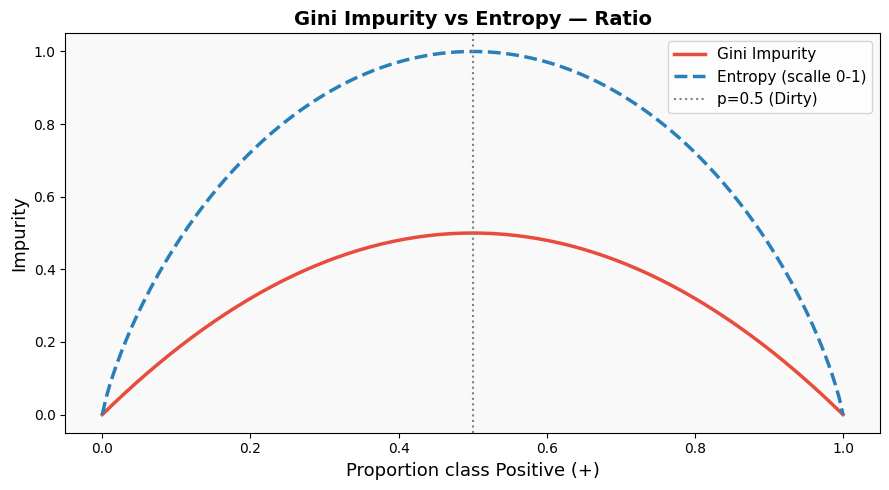

In [19]:
p = np.linspace(0, 1, 200)
gini_vals = 1 - p**2 - (1-p)**2
entropy_vals = np.where((p > 0) & (p < 1),
                        -(p*np.log2(p+1e-10) + (1-p)*np.log2(1-p+1e-10)), 0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p, gini_vals,    color='#E74C3C', lw=2.5, label='Gini Impurity')
ax.plot(p, entropy_vals, color='#2980B9', lw=2.5, linestyle='--', label='Entropy (scalle 0-1)')
ax.axvline(0.5, color='gray', linestyle=':', lw=1.5, label='p=0.5 (Dirty)')
ax.set_xlabel('Proportion class Positive (+)', fontsize=13)
ax.set_ylabel('Impurity', fontsize=13)
ax.set_title('Gini Impurity vs Entropy — Ratio', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_facecolor('#F9F9F9')
fig.tight_layout()
plt.show()

In [4]:
np.random.seed(42)
X, y = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)

df = pd.DataFrame(X, columns=['Fitur_A', 'Fitur_B'])
df['Label'] = y

print('Shape dataset:', df.shape)
print('\nDistribusi kelas:')
print(df['Label'].value_counts())
print('\nPreview 5 baris pertama:')
df.head()

Shape dataset: (200, 3)

Distribusi kelas:
Label
1    100
0    100
Name: count, dtype: int64

Preview 5 baris pertama:


,Fitur_A,Fitur_B,Label
0,-0.872929,0.013042,1
1,1.312935,2.770534,1
2,2.340428,2.420996,1
3,2.294548,-0.404380,1
4,0.944105,0.477241,1


In [22]:
def find_best_split(X, y):
    best = {'gini': float('inf'), 'fitur': None, 'threshold': None}
    results = []

    for fitur_idx in range(X.shape[1]):
        values = np.unique(X[:, fitur_idx])
        thresholds = (values[:-1] + values[1:]) / 2

        for thresh in thresholds:
            y_left  = y[X[:, fitur_idx] <= thresh]
            y_right = y[X[:, fitur_idx] >  thresh]
            g = gini_split(y_left, y_right)
            results.append({'Fitur': f'Fitur_{chr(65+fitur_idx)}',
                            'Threshold': round(thresh, 4),
                            'Gini Split': round(g, 4),
                            'n_left': len(y_left),
                            'n_right': len(y_right)})
            if g < best['gini']:
                best = {'gini': g, 'fitur': fitur_idx, 'threshold': thresh}

    return best, pd.DataFrame(results)

best, df_splits = find_best_split(X, y)

print(f"✅ Best Split Found")
print(f"   Fitur     : Fitur_{chr(65+best['fitur'])}")
print(f"   Threshold : {best['threshold']:.4f}")
print(f"   Gini Split: {best['gini']:.4f}")
print()
print('Top 10 split:')
df_splits.sort_values('Gini Split').head(10)

✅ Best Split Found
   Fitur     : Fitur_A
   Threshold : -0.0001
   Gini Split: 0.2467

Top 10 split:


,Fitur,Threshold,Gini Split,n_left,n_right
92,Fitur_A,-0.0001,0.2467,93,107
94,Fitur_A,0.0188,0.2473,95,105
91,Fitur_A,-0.0120,0.2534,92,108
93,Fitur_A,0.0091,0.2541,94,106
95,Fitur_A,0.0370,0.2546,96,104
97,Fitur_A,0.0741,0.2549,98,102
99,Fitur_A,0.1001,0.2550,100,100
110,Fitur_A,0.3080,0.2590,111,89
90,Fitur_A,-0.0423,0.2600,91,109
108,Fitur_A,0.2650,0.2600,109,91


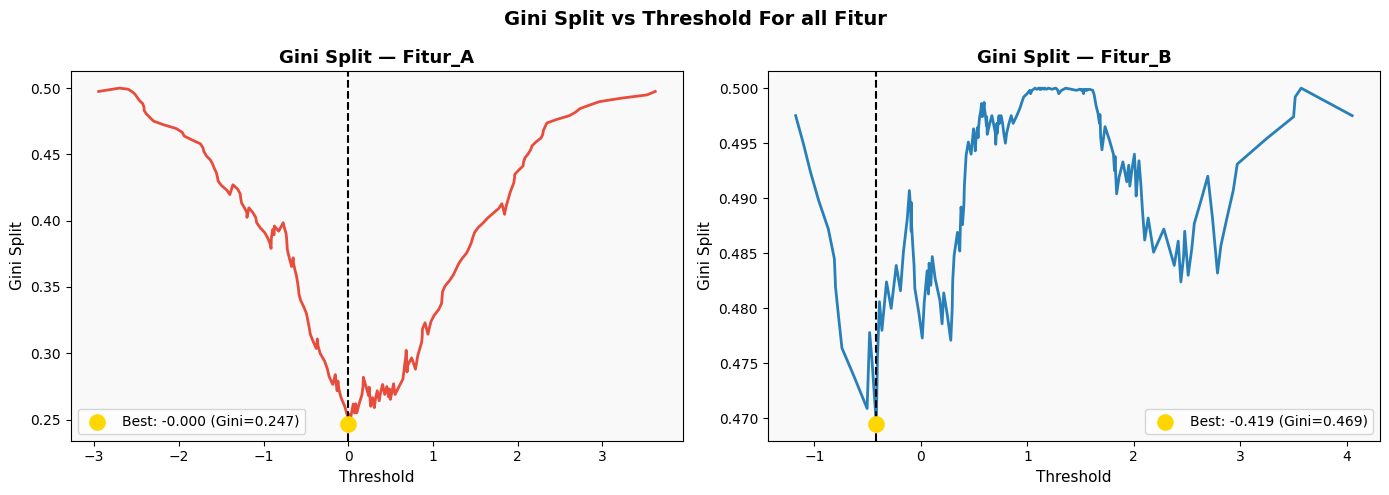

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#E74C3C', '#2980B9']

for i, fitur_name in enumerate(['Fitur_A', 'Fitur_B']):
    subset = df_splits[df_splits['Fitur'] == fitur_name].sort_values('Threshold')
    axes[i].plot(subset['Threshold'], subset['Gini Split'], color=colors[i], lw=2)
    min_row = subset.loc[subset['Gini Split'].idxmin()]
    axes[i].axvline(min_row['Threshold'], color='black', linestyle='--', lw=1.5)
    axes[i].scatter([min_row['Threshold']], [min_row['Gini Split']],
                    color='gold', s=120, zorder=5,
                    label=f"Best: {min_row['Threshold']:.3f} (Gini={min_row['Gini Split']:.3f})")
    axes[i].set_title(f'Gini Split — {fitur_name}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Threshold', fontsize=11)
    axes[i].set_ylabel('Gini Split', fontsize=11)
    axes[i].legend(fontsize=10)
    axes[i].set_facecolor('#F9F9F9')

fig.suptitle('Gini Split vs Threshold For all Fitur', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
model_gini.fit(X_train, y_train)

y_pred = model_gini.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print('=== Decision Tree (Gini) ===')
print(f'Akurasi : {acc:.4f} ({acc*100:.2f}%)')
print()
print(classification_report(y_test, y_pred))

=== Decision Tree (Gini) ===
Akurasi : 0.8800 (88.00%)

              precision    recall  f1-score   support

           0       0.96      0.83      0.89        30
           1       0.79      0.95      0.86        20

    accuracy                           0.88        50
   macro avg       0.88      0.89      0.88        50
weighted avg       0.89      0.88      0.88        50



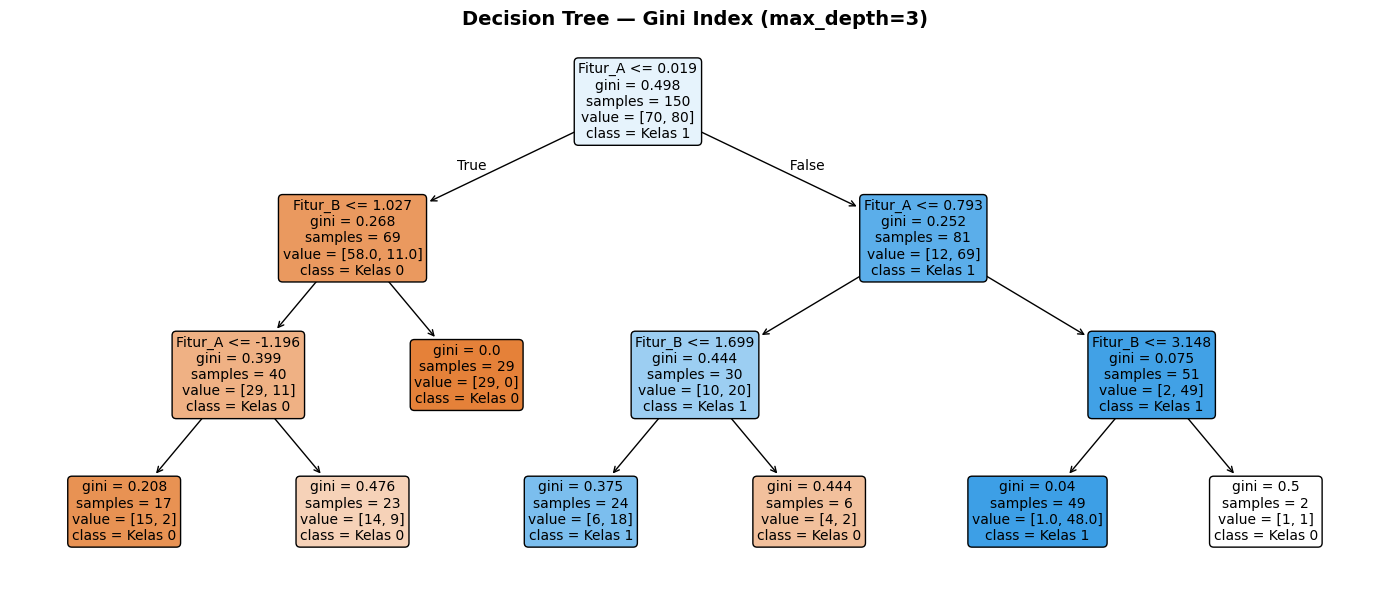


Decision Tree (teks):
|--- Fitur_A <= 0.02
|   |--- Fitur_B <= 1.03
|   |   |--- Fitur_A <= -1.20
|   |   |   |--- class: 0
|   |   |--- Fitur_A >  -1.20
|   |   |   |--- class: 0
|   |--- Fitur_B >  1.03
|   |   |--- class: 0
|--- Fitur_A >  0.02
|   |--- Fitur_A <= 0.79
|   |   |--- Fitur_B <= 1.70
|   |   |   |--- class: 1
|   |   |--- Fitur_B >  1.70
|   |   |   |--- class: 0
|   |--- Fitur_A >  0.79
|   |   |--- Fitur_B <= 3.15
|   |   |   |--- class: 1
|   |   |--- Fitur_B >  3.15
|   |   |   |--- class: 0



In [24]:
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(
    model_gini,
    feature_names=['Fitur_A', 'Fitur_B'],
    class_names=['Kelas 0', 'Kelas 1'],
    filled=True, rounded=True, fontsize=10, ax=ax
)
ax.set_title('Decision Tree — Gini Index (max_depth=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nDecision Tree (teks):')
print(export_text(model_gini, feature_names=['Fitur_A', 'Fitur_B']))

In [9]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

df_iris = pd.DataFrame(X_iris, columns=iris.feature_names)
df_iris['Species'] = [iris.target_names[i] for i in y_iris]

print('Dataset Iris:')
print(f'  Shape  : {X_iris.shape}')
print(f'  Kelas  : {iris.target_names.tolist()}')
print(f'  Fitur  : {iris.feature_names}')
print()
print('Distribusi kelas:')
print(df_iris['Species'].value_counts())
print()

g_root = gini_index(y_iris)
print(f'Gini Index Root Node (sebelum split): {g_root:.4f}')

Dataset Iris:
  Shape  : (150, 4)
  Kelas  : ['setosa', 'versicolor', 'virginica']
  Fitur  : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Distribusi kelas:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Gini Index Root Node (sebelum split): 0.6667


In [10]:
print('Gini Split terbaik per fitur (Iris Dataset):')
print('='*55)

for i, fname in enumerate(iris.feature_names):
    col = X_iris[:, i]
    thresholds = np.unique((np.sort(col)[:-1] + np.sort(col)[1:]) / 2)
    best_g, best_t = float('inf'), None

    for t in thresholds:
        yl = y_iris[col <= t]
        yr = y_iris[col >  t]
        g  = gini_split(yl, yr)
        if g < best_g:
            best_g, best_t = g, t

    gain = gini_index(y_iris) - best_g
    print(f'  {fname:<30} threshold={best_t:.2f}  gini={best_g:.4f}  gain={gain:.4f}')

print('='*55)
print('→ Fitur dengan Gini Split terkecil dipilih sebagai root!')

Gini Split terbaik per fitur (Iris Dataset):
  sepal length (cm)              threshold=5.40  gini=0.4389  gain=0.2278
  sepal width (cm)               threshold=3.30  gini=0.5397  gain=0.1269
  petal length (cm)              threshold=1.90  gini=0.3333  gain=0.3333
  petal width (cm)               threshold=0.80  gini=0.3333  gain=0.3333
→ Fitur dengan Gini Split terkecil dipilih sebagai root!


In [25]:
X_tr, X_te, y_tr, y_te = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

model_gini_iris    = DecisionTreeClassifier(criterion='gini',    max_depth=4, random_state=42)
model_entropy_iris = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

model_gini_iris.fit(X_tr, y_tr)
model_entropy_iris.fit(X_tr, y_tr)

acc_gini    = accuracy_score(y_te, model_gini_iris.predict(X_te))
acc_entropy = accuracy_score(y_te, model_entropy_iris.predict(X_te))

print('=== Gini vs Entropy (Iris) ===')
print(f'  Akurasi Gini     : {acc_gini:.4f} ({acc_gini*100:.2f}%)')
print(f'  Akurasi Entropy  : {acc_entropy:.4f} ({acc_entropy*100:.2f}%)')
print(f'  Kedalaman Gini   : {model_gini_iris.get_depth()}')
print(f'  Kedalaman Entropy: {model_entropy_iris.get_depth()}')
print(f'  Leaf Gini        : {model_gini_iris.get_n_leaves()}')
print(f'  Leaf Entropy     : {model_entropy_iris.get_n_leaves()}')

=== Gini vs Entropy (Iris) ===
  Akurasi Gini     : 1.0000 (100.00%)
  Akurasi Entropy  : 1.0000 (100.00%)
  Kedalaman Gini   : 4
  Kedalaman Entropy: 4
  Leaf Gini        : 7
  Leaf Entropy     : 7


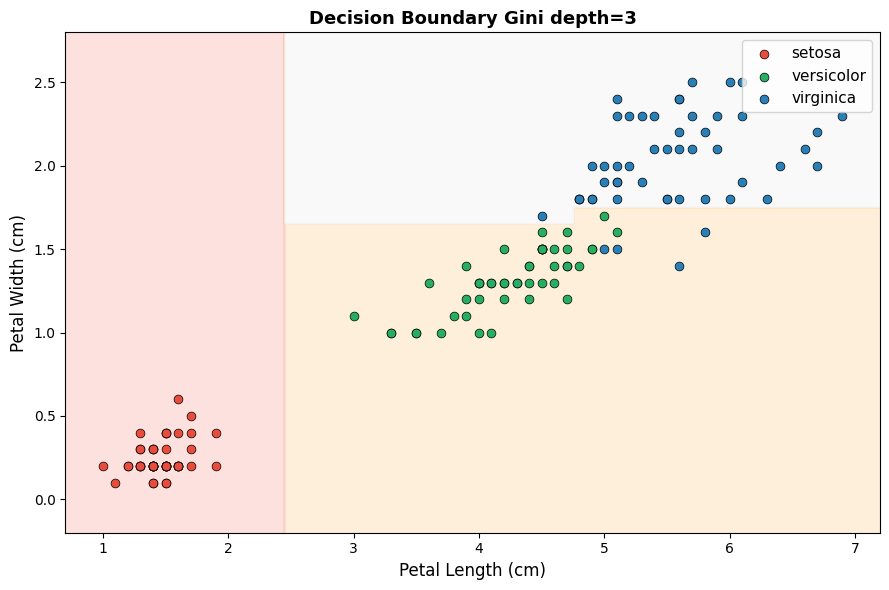

Akurasi test set: 1.0000


In [12]:
import matplotlib

X2 = X_iris[:, 2:4]
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y_iris, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf.fit(X2_tr, y2_tr)

xx, yy = np.meshgrid(
    np.linspace(X2[:,0].min()-0.3, X2[:,0].max()+0.3, 300),
    np.linspace(X2[:,1].min()-0.3, X2[:,1].max()+0.3, 300)
)
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cmap_bg   = matplotlib.colormaps['Pastel1'].resampled(3)
colors_pt = ['#E74C3C', '#27AE60', '#2980B9']

fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)

for cls, color in zip(range(3), colors_pt):
    mask = y_iris == cls
    ax.scatter(X2[mask, 0], X2[mask, 1], c=color, s=40,
               edgecolor='k', lw=0.5, label=iris.target_names[cls])

ax.set_xlabel('Petal Length (cm)', fontsize=12)
ax.set_ylabel('Petal Width (cm)', fontsize=12)
ax.set_title('Decision Boundary Gini depth=3', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
fig.tight_layout()
plt.show()

print(f'Akurasi test set: {accuracy_score(y2_te, clf.predict(X2_te)):.4f}')

In [13]:
data = pd.DataFrame({
    'Cuaca': ['Cerah','Cerah','Mendung','Hujan','Hujan','Hujan','Mendung','Cerah','Cerah','Hujan'],
    'Suhu': ['Panas','Panas','Panas','Sejuk','Dingin','Dingin','Dingin','Sejuk','Dingin','Sejuk'],
    'Main': ['Tidak','Tidak','Ya','Ya','Ya','Tidak','Ya','Tidak','Ya','Ya']
})

print('Dataset Bermain (10 sampel):')
print(data.to_string(index=False))
print()

y_all = (data['Main'] == 'Ya').astype(int).values
g_root = gini_index(y_all)
print(f'Gini Root : {g_root:.4f}')
print()

for cuaca in ['Cerah', 'Mendung', 'Hujan']:
    subset = data[data['Cuaca'] == cuaca]['Main']
    y_sub = (subset == 'Ya').astype(int).values
    g = gini_index(y_sub)
    print(f'Cuaca={cuaca} n={len(y_sub)} Gini={g:.4f}')

n = len(y_all)
g_cerah = gini_index((data[data['Cuaca']=='Cerah']['Main']=='Ya').astype(int).values)
g_mendung = gini_index((data[data['Cuaca']=='Mendung']['Main']=='Ya').astype(int).values)
g_hujan = gini_index((data[data['Cuaca']=='Hujan']['Main']=='Ya').astype(int).values)
n_c = sum(data['Cuaca']=='Cerah')
n_m = sum(data['Cuaca']=='Mendung')
n_h = sum(data['Cuaca']=='Hujan')

g_split_cuaca = (n_c/n)*g_cerah + (n_m/n)*g_mendung + (n_h/n)*g_hujan
print(f'\nGini Split Cuaca = {g_split_cuaca:.4f}')
print(f'Gini Gain Cuaca  = {g_root - g_split_cuaca:.4f}')

Dataset Bermain (10 sampel):
  Cuaca   Suhu  Main
  Cerah  Panas Tidak
  Cerah  Panas Tidak
Mendung  Panas    Ya
  Hujan  Sejuk    Ya
  Hujan Dingin    Ya
  Hujan Dingin Tidak
Mendung Dingin    Ya
  Cerah  Sejuk Tidak
  Cerah Dingin    Ya
  Hujan  Sejuk    Ya

Gini Root : 0.4800

Cuaca=Cerah n=4 Gini=0.3750
Cuaca=Mendung n=2 Gini=0.0000
Cuaca=Hujan n=4 Gini=0.3750

Gini Split Cuaca = 0.3000
Gini Gain Cuaca  = 0.1800


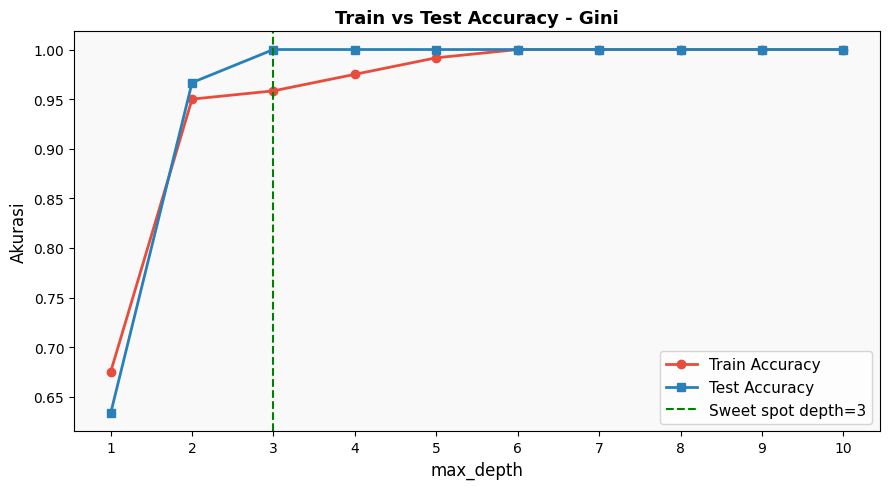


Ringkasan:
depth= 1 train=0.675 test=0.633 ███████████████████
depth= 2 train=0.950 test=0.967 █████████████████████████████
depth= 3 train=0.958 test=1.000 ██████████████████████████████
depth= 4 train=0.975 test=1.000 ██████████████████████████████
depth= 5 train=0.992 test=1.000 ██████████████████████████████
depth= 6 train=1.000 test=1.000 ██████████████████████████████
depth= 7 train=1.000 test=1.000 ██████████████████████████████
depth= 8 train=1.000 test=1.000 ██████████████████████████████
depth= 9 train=1.000 test=1.000 ██████████████████████████████
depth=10 train=1.000 test=1.000 ██████████████████████████████


In [14]:
depths = range(1, 11)
train_accs, test_accs = [], []

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

for d in depths:
    m = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=42)
    m.fit(X_tr2, y_tr2)
    train_accs.append(accuracy_score(y_tr2, m.predict(X_tr2)))
    test_accs.append(accuracy_score(y_te2, m.predict(X_te2)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths, train_accs, 'o-', color='#E74C3C', lw=2, label='Train Accuracy')
ax.plot(depths, test_accs, 's-', color='#2980B9', lw=2, label='Test Accuracy')
ax.axvline(3, color='green', linestyle='--', lw=1.5, label='Sweet spot depth=3')
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('Akurasi', fontsize=12)
ax.set_title('Train vs Test Accuracy - Gini', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_facecolor('#F9F9F9')
ax.set_xticks(list(depths))
fig.tight_layout()
plt.show()

print('\nRingkasan:')
for d, tr, te in zip(depths, train_accs, test_accs):
    bar = '█' * int(te * 30)
    print(f'depth={d:2d} train={tr:.3f} test={te:.3f} {bar}')

In [15]:
print('='*50)
print('  RINGKASAN GINI INDEX & GINI SPLIT')
print('='*50)
print()
print('1. GINI INDEX:')
print('   Gini(t) = 1 - sum(p_i^2)')
print('   0 = murni, mendekati 1 = campuran')
print()
print('2. GINI SPLIT:')
print('   = (n_kiri/n)*Gini(kiri)')
print('   + (n_kanan/n)*Gini(kanan)')
print('   Pilih split dengan nilai TERKECIL')
print()
print('3. GINI GAIN:')
print('   = Gini(parent) - Gini_split')
print('   Pilih split dengan nilai TERBESAR')
print()
print('4. SKLEARN:')
print('   DecisionTreeClassifier(criterion="gini")')
print()
print('5. GINI vs ENTROPY:')
print('   Gini    -> cepat, default sklearn')
print('   Entropy -> sensitif, dipakai ID3/C4.5')
print()
print('='*50)
print('Selesai!')
print('='*50)

  RINGKASAN GINI INDEX & GINI SPLIT

1. GINI INDEX:
   Gini(t) = 1 - sum(p_i^2)
   0 = murni, mendekati 1 = campuran

2. GINI SPLIT:
   = (n_kiri/n)*Gini(kiri)
   + (n_kanan/n)*Gini(kanan)
   Pilih split dengan nilai TERKECIL

3. GINI GAIN:
   = Gini(parent) - Gini_split
   Pilih split dengan nilai TERBESAR

4. SKLEARN:
   DecisionTreeClassifier(criterion="gini")

5. GINI vs ENTROPY:
   Gini    -> cepat, default sklearn
   Entropy -> sensitif, dipakai ID3/C4.5

Selesai!
